In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.options.display.max_seq_items = 2000

In [3]:
data = pd.read_pickle('reconciled_data.pkl')

In [4]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       'F_C31': 31, 'F_C32': 32,
       'F_C33': 33, 'F_C34': 34,
       # 'F_C35': 35, 
       # 'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       'F_Olef_C16': 16, 'F_Olef_C17': 17, 
       'F_Olef_C18': 18, 
}

In [5]:
Fn_exp_parafins = data[list(Ns_parafins.keys())]

Fn_exp_olefins = data[list(Ns_olefins.keys())]

Fn_exp_parafins.columns = Ns_parafins.values()
Fn_exp_parafins.columns = Fn_exp_parafins.columns.astype('int32')

Fn_exp_olefins.columns = Ns_olefins.values()
Fn_exp_olefins.columns = Fn_exp_olefins.columns.astype('int32')

In [6]:
Fn_exp = Fn_exp_parafins.copy()

In [7]:
for i in Ns_olefins.values():
    Fn_exp[i] = Fn_exp[i] + Fn_exp_olefins[i]

In [8]:
# drop rows with zeros
Fn_exp = Fn_exp[(Fn_exp != 0).all(axis=1)]
Fn_exp = Fn_exp.astype('float')

In [9]:
yn_exp = Fn_exp.div(Fn_exp.sum(axis = 'columns'), axis = 'rows')

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [11]:
alphas = data[['T_R_K', 'H2_CO', 'P_abs_Pa']]

In [12]:
for i in yn_exp.index:
    x = (yn_exp.columns.values - 1).reshape(-1, 1)
    y = np.log(yn_exp.loc[i].values)
    
    # Optional: Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train) # Fit the model to the training data
    
    r_sq = model.score(X_test, y_test) # Evaluate on the test set

    alphas.loc[i, 'alpha'] = np.exp(model.coef_[0])
    alphas.loc[i, 'R² alpha'] = r_sq

In [13]:
alphas = alphas.astype('float')

In [14]:
alphas.columns

Index(['T_R_K', 'H2_CO', 'P_abs_Pa', 'alpha', 'R² alpha'], dtype='str')

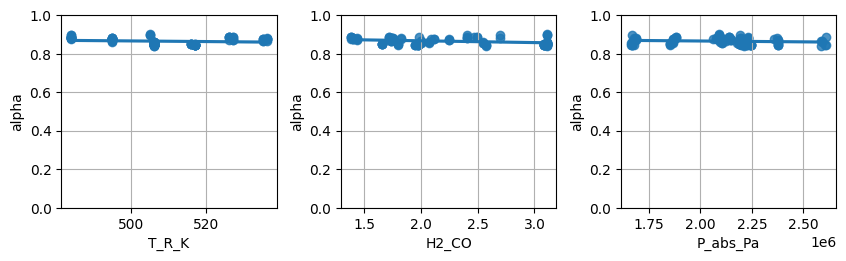

In [15]:
fig, ax = plt.subplots(1,3,figsize=(10,2.5))
plt.subplots_adjust(wspace=0.3)

sns.regplot(x='T_R_K', y='alpha', data=alphas, ax = ax[0])
ax[0].grid('both')
ax[0].set_ylim(0,1)

sns.regplot(x='H2_CO', y='alpha', data=alphas, ax = ax[1])
ax[1].grid('both')
ax[1].set_ylim(0,1)

sns.regplot(x='P_abs_Pa', y='alpha', data=alphas, ax = ax[2])
ax[2].grid('both')
ax[2].set_ylim(0,1)


plt.show()

In [16]:
# visualizing yn
yn_plot = yn_exp.copy()
yn_plot['T_R_K'] = data.T_R_K
yn_plot['T_R_C'] = data.T_R_C
yn_plot['H2_CO'] = data.H2_CO
yn_plot['P_Pa'] = data.P_abs_Pa
yn_plot = yn_plot.melt(id_vars = ['T_R_K', 'T_R_C', 'H2_CO', 'P_Pa'], value_name = 'yn_exp', var_name = 'n')
yn_plot['mean_alpha'] = alphas.alpha.mean()
yn_plot['yn_model'] = ( 1 - yn_plot.mean_alpha.values ) * yn_plot.mean_alpha.values ** ( yn_plot.n.values - 1 )

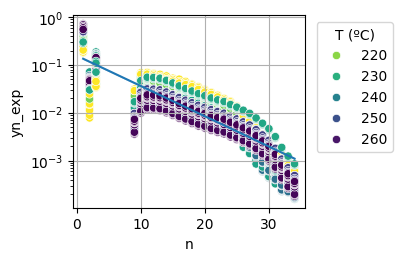

In [17]:
fig, ax = plt.subplots(figsize=(3, 2.5))
sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot, ax = ax, hue = 'T_R_C', palette = 'viridis_r')

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax)

plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1), title = 'T (ºC)')
plt.yscale('log')
plt.show()

In [18]:
alphas.alpha.mean()

np.float64(0.864371838560974)

In [19]:
alphas.alpha.std()

np.float64(0.016502587517646005)

In [20]:
np.save('param_alpha.npy', alphas.alpha.mean())